In [1]:
import numpy as np
import znnl as nl
import numpy as onp
import pandas as pd

from neural_tangents import stax
import optax

import matplotlib.pyplot as plt

import h5py as hf
from scipy.stats import pearsonr

Using backend: cpu

Available hardware:

TFRT_CPU_0

## Download the data

In [2]:
generator = nl.data.MNISTGenerator(ds_size=1000)

## Create the model

In [3]:
def create_model(generator = generator, alpha: float = 1.0, ds_size: int = 500, subset_size: int = 0.3):
    network = stax.serial(
        stax.Flatten(),
        stax.Dense(128),
        stax.Relu(),
        stax.Dense(128),
        stax.Relu(),
        stax.Dense(10),
    )
    
    indices = onp.random.randint(
        0, generator.train_ds["inputs"].shape[0] - 1, size=(ds_size,)
    )
    
    train_ds = {
        "inputs": np.take(generator.train_ds["inputs"], indices, axis=0),
        "targets": np.take(generator.train_ds["targets"], indices, axis=0)
    }
    
    optimizer = nl.optimizers.TraceOptimizer(
        scale_factor=alpha, subset=subset_size
    )
    model = nl.models.NTModel(
                nt_module=network,
                optimizer=optimizer,
                input_shape=(1, 28, 28, 1),
                batch_size=5
        )
    
    return model, train_ds
    

# Trace Convergence

Here we want to assess whether the NTK trace converges for some data-set size. 
We do this by training models using larger data-sets and recording the trace for each one.
In all cases, we take 100 epochs and use the trace optimizer.

In [4]:
ds_sizes = [10, 100, 200, 300]
    
model, train_ds = create_model(ds_size=500, subset_size=0.3)

train_recorder = nl.training_recording.JaxRecorder(
    name=f"trace-convergence/sub_train_recorder",
    ntk=True,
    loss=True,
    trace=True,
    eigenvalues=True,
    update_rate=1
)

test_recorder = nl.training_recording.JaxRecorder(
    name=f"trace-convergence/sub_test_recorder",
    loss=True,
    update_rate=1
)

subset_recorders = [
    nl.training_recording.JaxRecorder(
        name=f"trace-convergence/sub_train_recorder_{item}",
        loss=True,
        trace=True,
        eigenvalues=True,
        subset=item,
        update_rate=1
    )
    for item in ds_sizes
]

train_recorder.instantiate_recorder(
data_set=train_ds
)
test_recorder.instantiate_recorder(
    data_set=generator.test_ds
)

for item in subset_recorders:
    item.instantiate_recorder(train_ds)

training_strategy = nl.training_strategies.SimpleTraining(
    model=model, 
    loss_fn=nl.loss_functions.LPNormLoss(order=2),
    recorders=[train_recorder, test_recorder] + subset_recorders
)

_ = training_strategy.train_model(
    train_ds=train_ds, test_ds=generator.test_ds, epochs=30, batch_size=128
)
train_recorder.dump_records()
test_recorder.dump_records()
for item in subset_recorders:
    item.dump_records()

Epoch: 30: 100%|█████████████████████████████████| 30/30 [10:21<00:00, 20.71s/batch, test_loss=0.92]


In [7]:
def load_data(file):
    with hf.File(file, "r") as db:
        data = db["trace"][:]
        
    return data

In [8]:
ds_sizes = [10, 100, 200, 300]
data = {}

data[500] = load_data("trace-convergence/sub_train_recorder.h5")

for item in ds_sizes:
    data[item] = load_data(f"trace-convergence/sub_train_recorder_{item}.h5") 

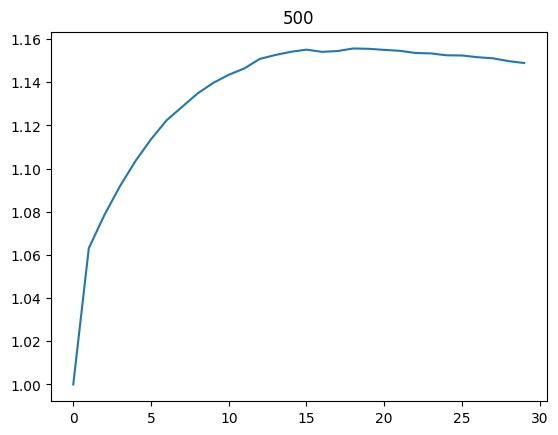

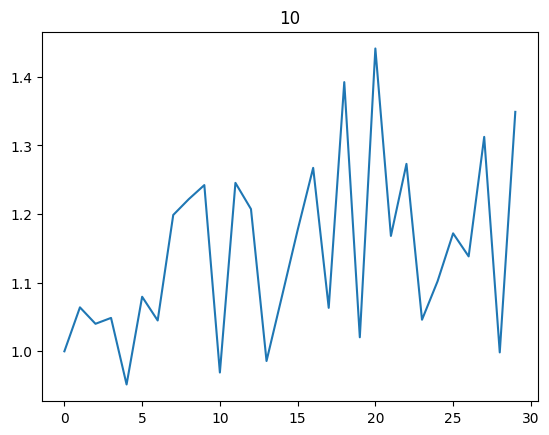

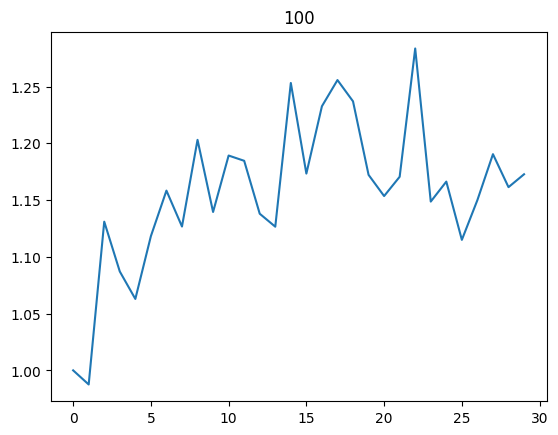

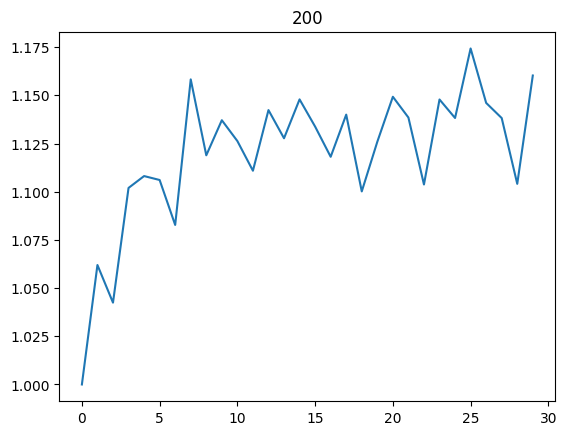

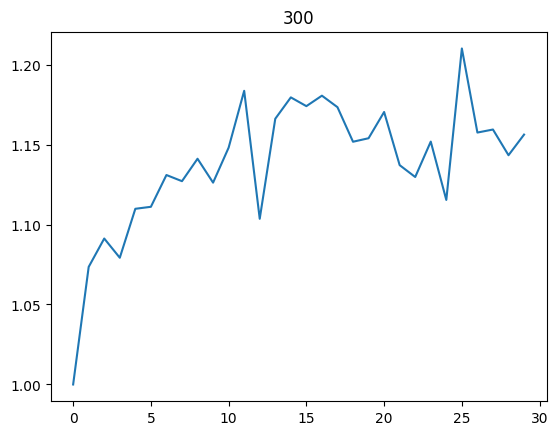

In [9]:
for item in data:
    plt.plot(data[item][0] / data[item])
    plt.title(item)
    plt.show()

In [14]:
y = []
yerr = []
x = list(data)

for item in data:
    difference = abs(data[500][0] / data[500] - data[item][0] / data[item])
    y.append(np.mean(difference))
    yerr.append(np.std(difference))


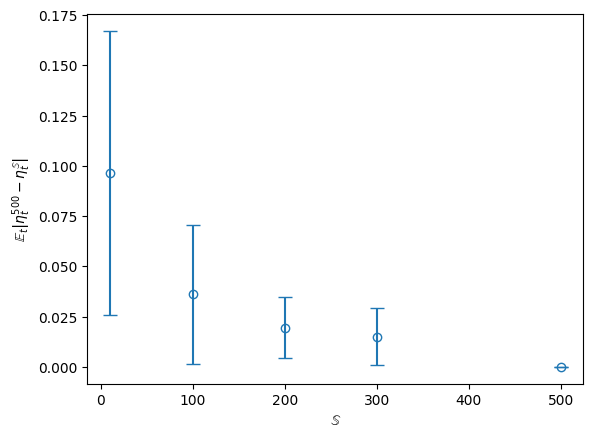

In [28]:
plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="none", mfc="none", capsize=5)
plt.xlabel(r"$\mathbb{S}$")
plt.ylabel(r"$\mathbb{E}_{t}\left|\eta^{500}_{t} - \eta^{\mathbb{S}}_{t}\right|$")
plt.savefig("mnist-trace-convergence.pdf")
plt.show()